In [ ]:
import pandas as pd
import numpy as np

deliveries = pd.read_csv('../data/deliveries.csv')
matches = pd.read_csv('../data/matches.csv')

In [ ]:
# Virat Kohli performance against each team
virat = deliveries[deliveries['batter'] == 'V Kohli']
virat.groupby('bowling_team')['batsman_runs'].sum().sort_values(ascending=False)

In [ ]:
# Rohit Sharma strike rate vs CSK
csk = deliveries[
    (deliveries['batter'].isin(['R Sharma', 'RG Sharma'])) &
    (deliveries['bowling_team'] == 'Chennai Super Kings')
]

(csk['batsman_runs'].sum() /
 csk[csk['extras_type'] != 'wides'].shape[0]) * 100

In [ ]:
# Most wickets against RCB
bowlers = deliveries[
    (deliveries['batting_team'] == 'Royal Challengers Bangalore') &
    (deliveries['is_wicket'] == 1) &
    (~deliveries['dismissal_kind'].isin(['run out','retired hurt','obstructing the field','retired out']))
    ]
bowlers['bowler'].value_counts().sort_values(ascending=False).head(1)

In [ ]:
# Batsman dismissed most by a bowler
dismissals = deliveries[
        (deliveries['is_wicket'] == 1) &
        (~deliveries['dismissal_kind'].isin(['run out','retired hurt','obstructing the field','retired out']))
    ]
dismissals.groupby('batter')['bowler'].count().sort_values(ascending=False)

In [ ]:
# Bowler dismissed same batsman most times
dismissals = deliveries[
    (deliveries['is_wicket'] == 1) &
    (~deliveries['dismissal_kind'].isin([
        'run out',
        'retired hurt',
        'obstructing the field',
        'retired out'
    ]))
]

dismissals.groupby(['batter', 'bowler'])['is_wicket'] \
    .count() \
    .sort_values(ascending=False) \
    .head(1)

In [ ]:
# Best batsman vs MI
batsman = deliveries[deliveries['bowling_team'] == 'Mumbai Indians']
batsman.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(1)

In [ ]:
# Best powerplay batsman
powerplay = deliveries[deliveries['over'] <= 5]
powerplay.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False)

In [ ]:
# Best bowler in powerplay
powerplay = deliveries[deliveries['over'] <= 5]
powerplay.groupby('bowler')['total_runs'].sum().sort_values()

In [ ]:
# Most runs scored in one over
# deliveries[(deliveries['over'] == 19) & (deliveries['match_id'] == 1254076) & (deliveries['inning'] == 1)]
deliveries.groupby(['over','match_id','inning'])['total_runs'].sum().reset_index().sort_values(by='total_runs',ascending=False).head(1)

In [90]:
# Most dot balls in death overs
death = deliveries[(deliveries['over'] >=15)]
death.groupby(['match_id','over'])['total_runs'].sum().reset_index().sort_values(by='total_runs')

,match_id,over,total_runs
841,419164,18,0
4299,1304054,18,0
3233,1136592,17,0
122,336006,19,0
129,336008,16,0
...,...,...,...
5196,1426280,17,49
4456,1304086,19,50
4687,1359487,19,51
3686,1216496,19,51


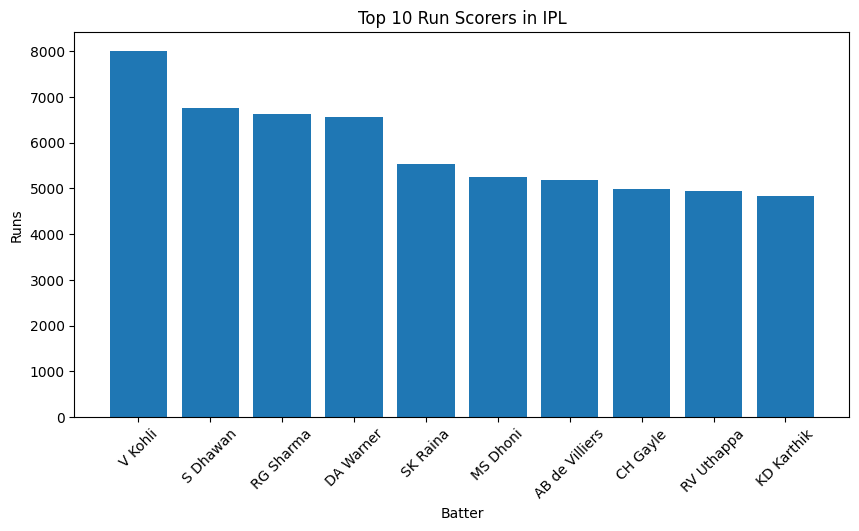

In [98]:
import matplotlib.pyplot as plt

# Top 10 run scorers
top_batters = deliveries.groupby('batter')['batsman_runs'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(10)

# Plot
plt.figure(figsize=(10, 5))

plt.bar(top_batters.index, top_batters.values)

plt.xlabel('Batter')
plt.ylabel('Runs')
plt.title('Top 10 Run Scorers in IPL')

plt.xticks(rotation=45)

# Save image
plt.savefig('../charts/top_10_batters.png')

# Show plot
plt.show()